<a href="https://colab.research.google.com/github/elajeans/IMAG2023/blob/main/Oppgave4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

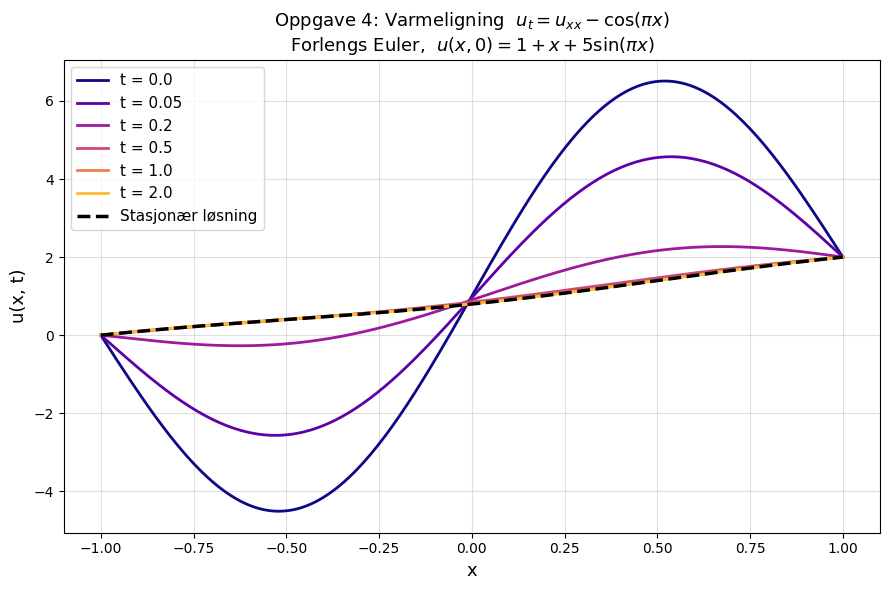

dt=3.96e-05, dx=0.0100, r=dt/dx²=0.4000


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================
# OPPGAVE 4: Varmeligning 1D
# u_t = u_xx - cos(πx),  t>=0, -1<x<1
# Initialbetingelse: u(x,0) = 1 + x + 5*sin(πx)
# Randbetingelser:   u(-1,t) = 0,  u(1,t) = 2
# Metode: Forlengs Euler (eksplisitt)
# =============================================================

M  = 200
dx = 2.0 / (M + 1)
x  = np.linspace(-1, 1, M + 2)
dt = 0.4 * dx**2   # stabilitetsvilkår: r = dt/dx² < 0.5
T  = 2.0
Nt = int(T / dt)

# Initialfelt
u = 1 + x + 5 * np.sin(np.pi * x)
u[0] = 0;  u[-1] = 2

f = np.cos(np.pi * x)

# Lagre løsningen ved utvalgte tidspunkter
save_times = [0.0, 0.05, 0.2, 0.5, 1.0, 2.0]
saved = {0.0: u.copy()}

t = 0.0
for n in range(Nt):
    u_new = u.copy()
    u_new[1:-1] = u[1:-1] + dt * (
        (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2 - f[1:-1]
    )
    u_new[0] = 0;  u_new[-1] = 2
    u = u_new
    t += dt
    for ts in save_times[1:]:
        if ts not in saved and abs(t - ts) < dt/2:
            saved[ts] = u.copy()

# Stasjonær løsning (fra oppgave 3)
def u_stasjonaer(x):
    return -np.cos(np.pi * x) / np.pi**2 + x + 1 - 1/np.pi**2

# --- Plot ---
x_fine = np.linspace(-1, 1, 500)
fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.plasma(np.linspace(0, 0.85, len(save_times)))
for i, ts in enumerate(save_times):
    if ts in saved:
        ax.plot(x, saved[ts], color=colors[i], linewidth=2, label=f't = {ts}')
ax.plot(x_fine, u_stasjonaer(x_fine), 'k--', linewidth=2.5,
        label='Stasjonær løsning', zorder=5)
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('u(x, t)', fontsize=13)
ax.set_title('Oppgave 4: Varmeligning  $u_t = u_{xx} - \\cos(\\pi x)$\n'
             'Forlengs Euler,  $u(x,0)=1+x+5\\sin(\\pi x)$', fontsize=13)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
print(f"dt={dt:.2e}, dx={dx:.4f}, r=dt/dx²={dt/dx**2:.4f}")